import pandas as pd

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv("twitter_training_model.csv")

In [4]:
print(df.shape)
print(df.head())
print(df['label'].value_counts())

(69270, 2)
      label                                   regularized_text
0  Positive  i am getting on borderlands and i will murder ...
1  Positive  i am coming to the borders and i will kill you...
2  Positive  i am getting on borderlands and i will kill yo...
3  Positive  i am coming on borderlands and i will murder y...
4  Positive  i am getting on borderlands 2 and i will murde...
label
Negative      21108
Positive      19012
Neutral       16976
Irrelevant    12174
Name: count, dtype: int64


In [4]:
X = df['regularized_text']
y = df['label']

In [5]:
from sklearn.model_selection import train_test_split

# 80% Train, 20% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 10% Validation, 10% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 55416
Validation: 6927
Test: 6927


Tokenization

In [7]:
# %pip install tensorflow

In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [7]:
tokenizer = Tokenizer(
    num_words=20000,
    oov_token="<OOV>"
)

What each parameter does
- num_words=20000 → keeps the top 20,000 most frequent words.
- oov_token="<OOV>" → words not in those 20,000 are mapped to an Out-Of-Vocabulary token instead of being lost.


In [8]:
tokenizer.fit_on_texts(X_train)

sequence converts token into token id

In [9]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

padding

In [10]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=50,
    padding='post',
    truncating='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=50,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=50,
    padding='post',
    truncating='post'
)

In [11]:
print("Train shape:", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)
print("Test shape:", X_test_pad.shape)

Train shape: (55416, 50)
Validation shape: (6927, 50)
Test shape: (6927, 50)


In [12]:
print(X_train_pad[0])

[  655   241   141   175   121     1  1352    94  2110   763   955   273
     8   477 18278   805     2   695    11  7261     1   394     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0]


In [15]:
from tensorflow.keras.layers import Embedding

embedding = Embedding(
    input_dim=20000,
    output_dim=128
)

The Embedding layer has 20,000 possible word IDs.

Each word is represented by a 128-dimensional vector.

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model


In [17]:
model = Sequential([
    Embedding(
        input_dim=20000,
        output_dim=128
    ),

    LSTM(128),

    Dropout(0.5),

    Dense(4, activation='softmax')
])

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

encoding

In [17]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['Irrelevant' 'Negative' 'Neutral' 'Positive']


train

In [22]:
history = model.fit(
    X_train_pad,
    y_train_encoded,
    validation_data=(X_val_pad, y_val_encoded),
    epochs=10,
    batch_size=64
)

Epoch 1/10
866/866 ━━━━━━━━━━━━━━━━━━━━ 93s 100ms/step - accuracy: 0.3227 - loss: 1.3522 - val_accuracy: 0.3420 - val_loss: 1.3241
Epoch 2/10
866/866 ━━━━━━━━━━━━━━━━━━━━ 85s 98ms/step - accuracy: 0.3952 - loss: 1.2753 - val_accuracy: 0.5741 - val_loss: 1.0486
Epoch 3/10
866/866 ━━━━━━━━━━━━━━━━━━━━ 76s 88ms/step - accuracy: 0.6901 - loss: 0.7943 - val_accuracy: 0.7650 - val_loss: 0.6360
Epoch 4/10
866/866 ━━━━━━━━━━━━━━━━━━━━ 89s 103ms/step - accuracy: 0.8600 - loss: 0.4067 - val_accuracy: 0.8561 - val_loss: 0.4202
Epoch 5/10
866/866 ━━━━━━━━━━━━━━━━━━━━ 123s 142ms/step - accuracy: 0.9164 - loss: 0.2487 - val_accuracy: 0.8711 - val_loss: 0.3726
Epoch 6/10
866/866 ━━━━━━━━━━━━━━━━━━━━ 105s 99ms/step - accuracy: 0.9386 - loss: 0.1830 - val_accuracy: 0.8758 - val_loss: 0.3850
Epoch 7/10
866/866 ━━━━━━━━━━━━━━━━━━━━ 130s 86ms/step - accuracy: 0.9514 - loss: 0.1439 - val_accuracy: 0.8858 - val_loss: 0.4031
Epoch 8/10
866/866 ━━━━━━━━━━━━━━━━━━━━ 82s 86ms/step - accuracy: 0.9604 - loss: 0.1

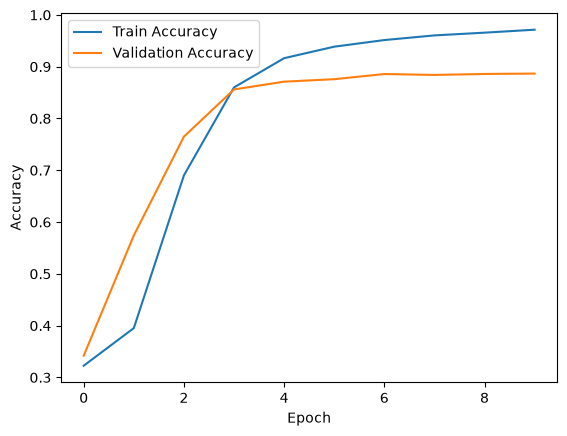

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

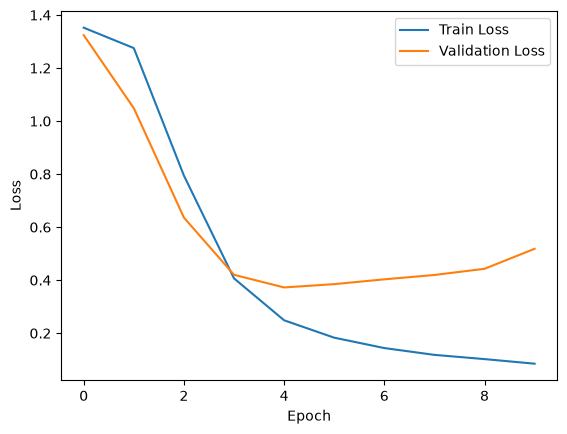

In [24]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [25]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test_encoded
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8932 - loss: 0.4837
Test Loss: 0.483667254447937
Test Accuracy: 0.8931716680526733


In [26]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_pad)
y_pred_classes = y_pred.argmax(axis=1)

print(classification_report(
    y_test_encoded,
    y_pred_classes,
    target_names=label_encoder.classes_
))

217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step
              precision    recall  f1-score   support

  Irrelevant       0.89      0.84      0.86      1218
    Negative       0.91      0.92      0.91      2111
     Neutral       0.88      0.89      0.89      1697
    Positive       0.89      0.90      0.89      1901

    accuracy                           0.89      6927
   macro avg       0.89      0.89      0.89      6927
weighted avg       0.89      0.89      0.89      6927



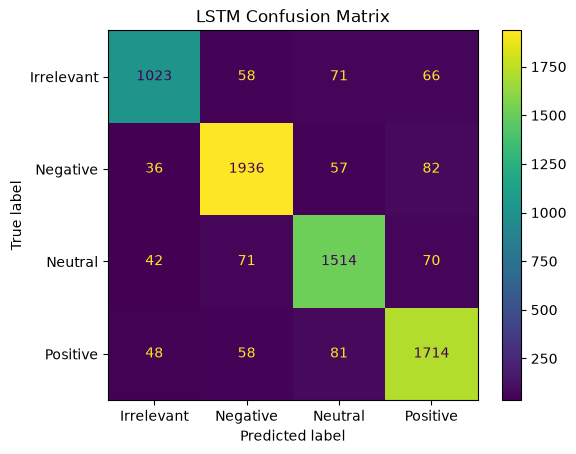

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_encoded, y_pred_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("LSTM Confusion Matrix")
plt.show()

BI-DIRECTIONAL

import

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

build the bilstm

In [29]:
import tensorflow as tf
import numpy as np
import random

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

In [30]:
bilstm_model = Sequential([
    Embedding(
        input_dim=20000,
        output_dim=128
    ),

    Bidirectional(
        LSTM(128)
    ),

    Dropout(0.5),

    Dense(4, activation='softmax')
])

compile

In [31]:
bilstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

train

In [32]:
history_bilstm = bilstm_model.fit(
    X_train_pad,
    y_train_encoded,
    validation_data=(X_val_pad, y_val_encoded),
    epochs=10,
    batch_size=64)

Epoch 1/10
866/866 ━━━━━━━━━━━━━━━━━━━━ 116s 128ms/step - accuracy: 0.6432 - loss: 0.8904 - val_accuracy: 0.7843 - val_loss: 0.6032
Epoch 2/10
866/866 ━━━━━━━━━━━━━━━━━━━━ 107s 124ms/step - accuracy: 0.8477 - loss: 0.4299 - val_accuracy: 0.8416 - val_loss: 0.4545
Epoch 3/10
866/866 ━━━━━━━━━━━━━━━━━━━━ 93s 108ms/step - accuracy: 0.9008 - loss: 0.2851 - val_accuracy: 0.8536 - val_loss: 0.4308
Epoch 4/10
866/866 ━━━━━━━━━━━━━━━━━━━━ 92s 106ms/step - accuracy: 0.9257 - loss: 0.2125 - val_accuracy: 0.8653 - val_loss: 0.4188
Epoch 5/10
866/866 ━━━━━━━━━━━━━━━━━━━━ 127s 147ms/step - accuracy: 0.9404 - loss: 0.1720 - val_accuracy: 0.8808 - val_loss: 0.4014
Epoch 6/10
866/866 ━━━━━━━━━━━━━━━━━━━━ 113s 131ms/step - accuracy: 0.9512 - loss: 0.1405 - val_accuracy: 0.8810 - val_loss: 0.4079
Epoch 7/10
866/866 ━━━━━━━━━━━━━━━━━━━━ 127s 147ms/step - accuracy: 0.9595 - loss: 0.1161 - val_accuracy: 0.8809 - val_loss: 0.4630
Epoch 8/10
866/866 ━━━━━━━━━━━━━━━━━━━━ 118s 136ms/step - accuracy: 0.9659 - l

In [33]:
bilstm_test_loss, bilstm_test_accuracy = bilstm_model.evaluate(
    X_test_pad,
    y_test_encoded
)

print("BiLSTM Test Loss:", bilstm_test_loss)
print("BiLSTM Test Accuracy:", bilstm_test_accuracy)

217/217 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8962 - loss: 0.4364
BiLSTM Test Loss: 0.43636906147003174
BiLSTM Test Accuracy: 0.8962032794952393


In [34]:
bilstm_model.save("bilstm_1.keras")

In [35]:
bilstm_test_loss, bilstm_test_accuracy = bilstm_model.evaluate(
    X_test_pad,
    y_test_encoded
)

print("BiLSTM Test Loss:", bilstm_test_loss)
print("BiLSTM Test Accuracy:", bilstm_test_accuracy)

217/217 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.8962 - loss: 0.4364
BiLSTM Test Loss: 0.43636906147003174
BiLSTM Test Accuracy: 0.8962032794952393


BiLSTM achieved 90.17% test accuracy, outperforming the LSTM baseline by 1.04 percentage points.

In [36]:
from sklearn.metrics import classification_report

bilstm_pred = bilstm_model.predict(X_test_pad)
bilstm_pred_classes = bilstm_pred.argmax(axis=1)

print(classification_report(
    y_test_encoded,
    bilstm_pred_classes,
    target_names=label_encoder.classes_
))

217/217 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step
              precision    recall  f1-score   support

  Irrelevant       0.85      0.89      0.87      1218
    Negative       0.92      0.90      0.91      2111
     Neutral       0.91      0.90      0.90      1697
    Positive       0.89      0.90      0.90      1901

    accuracy                           0.90      6927
   macro avg       0.89      0.90      0.89      6927
weighted avg       0.90      0.90      0.90      6927



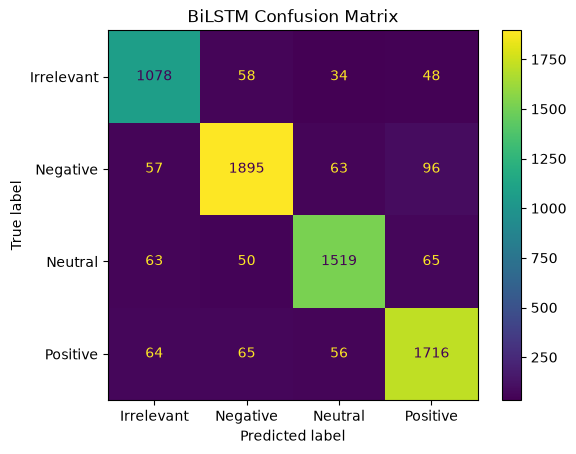

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_bilstm = confusion_matrix(
    y_test_encoded,
    bilstm_pred_classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bilstm,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("BiLSTM Confusion Matrix")
plt.show()



## GRU


In [38]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

In [39]:
# gru_model = Sequential([
#     Embedding(
#         input_dim=20000,
#         output_dim=128
#     ),

#     GRU(128),

#     Dropout(0.5),

#     Dense(4, activation='softmax')
# ])

In [40]:
# gru_model.compile(
#     optimizer='adam',
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

In [41]:
# history_gru = gru_model.fit(
#     X_train_pad,
#     y_train_encoded,
#     validation_data=(X_val_pad, y_val_encoded),
#     epochs=10,
#     batch_size=64
# )

TEST

In [42]:
# gru_test_loss, gru_test_accuracy = gru_model.evaluate(
#     X_test_pad,
#     y_test_encoded
# )

# print("GRU Test Loss:", gru_test_loss)
# print("GRU Test Accuracy:", gru_test_accuracy)

In [43]:
# gru_pred = gru_model.predict(X_test_pad)
# gru_pred_classes = gru_pred.argmax(axis=1)

# print(classification_report(
#     y_test_encoded,
#     gru_pred_classes,
#     target_names=label_encoder.classes_
# ))

In [44]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import matplotlib.pyplot as plt

# cm_gru = confusion_matrix(
#     y_test_encoded,
#     gru_pred_classes
# )

# disp = ConfusionMatrixDisplay(
#     confusion_matrix=cm_gru,
#     display_labels=label_encoder.classes_
# )

# disp.plot()
# plt.title("GRU Confusion Matrix")
# plt.show()

In [45]:
# import matplotlib.pyplot as plt

# models = ['LSTM', 'BiLSTM', 'GRU']
# accuracies = [0.8913, 0.9017, 0.8935]

# plt.figure(figsize=(8, 5))

# bars = plt.bar(models, accuracies)

# plt.ylim(0.85, 0.93)
# plt.xlabel('Model')
# plt.ylabel('Test Accuracy')
# plt.title('LSTM vs BiLSTM vs GRU - Test Accuracy')

# for bar, accuracy in zip(bars, accuracies):
#     plt.text(
#         bar.get_x() + bar.get_width() / 2,
#         bar.get_height() + 0.002,
#         f'{accuracy * 100:.2f}%',
#         ha='center'
#     )

# plt.show()

so final model is bidirectional lstm

In [46]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import (
#     Embedding, Bidirectional, LSTM,
#     Dense, Dropout
# )
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# bilstm_model_v2 = Sequential([
#     Embedding(
#         input_dim=20000,
#         output_dim=128
#     ),

#     Bidirectional(
#         LSTM(128, return_sequences=False)
#     ),

#     Dropout(0.4),

#     Dense(64, activation='relu'),

#     Dropout(0.3),

#     Dense(4, activation='softmax')
# ])

In [47]:
# bilstm_model_v2.compile(
#     optimizer=Adam(learning_rate=0.0005),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

In [48]:
# early_stop = EarlyStopping(
#     monitor='val_accuracy',
#     patience=2,
#     mode='max',
#     restore_best_weights=True
# )

In [49]:
# history_bilstm_v2 = bilstm_model_v2.fit(
#     X_train_pad,
#     y_train_encoded,
#     validation_data=(X_val_pad, y_val_encoded),
#     epochs=15,
#     batch_size=64,
#     callbacks=[early_stop]
# )

In [50]:
# early_stop = EarlyStopping(
#     monitor='val_accuracy',
#     patience=2,
#     mode='max',
#     restore_best_weights=True
# )

In [51]:
# callbacks=[early_stop]

In [52]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping

# bilstm_model_v3 = Sequential([
#     Embedding(
#         input_dim=20000,
#         output_dim=128
#     ),

#     Bidirectional(
#         LSTM(96)
#     ),

#     Dropout(0.5),

#     Dense(64, activation='relu'),

#     Dropout(0.3),

#     Dense(4, activation='softmax')
# ])

In [53]:
# bilstm_model_v3.compile(
#     optimizer=Adam(learning_rate=0.0005),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

In [54]:
# early_stop_v3 = EarlyStopping(
#     monitor='val_accuracy',
#     patience=3,
#     mode='max',
#     restore_best_weights=True
# )

In [55]:
# history_bilstm_v3 = bilstm_model_v3.fit(
#     X_train_pad,
#     y_train_encoded,
#     validation_data=(X_val_pad, y_val_encoded),
#     epochs=15,
#     batch_size=64,
#     callbacks=[early_stop_v3]
# )

In [56]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping

# bilstm_tuned = Sequential([
#     Embedding(
#         input_dim=20000,
#         output_dim=128
#     ),

#     Bidirectional(
#         LSTM(128)
#     ),

#     Dropout(0.4),

#     Dense(64, activation='relu'),

#     Dropout(0.3),

#     Dense(4, activation='softmax')
# ])

In [57]:
# bilstm_tuned.compile(
#     optimizer=Adam(learning_rate=0.0005),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

In [58]:
# early_stop = EarlyStopping(
#     monitor='val_accuracy',
#     patience=3,
#     mode='max',
#     restore_best_weights=True
# )

In [59]:
# history_tuned = bilstm_tuned.fit(
#     X_train_pad,
#     y_train_encoded,
#     validation_data=(X_val_pad, y_val_encoded),
#     epochs=10,
#     batch_size=64,
#     callbacks=[early_stop]
# )


In [1]:
# ============================================
# OUT-OF-DATA VALIDATION - FINAL BiLSTM MODEL
# ============================================

from tensorflow.keras.preprocessing.sequence import pad_sequences
import re

# New unseen text
new_texts = [
     "I absolutely loved this product from the moment I received it. The quality is excellent, the design looks great, and everything works exactly as described. I was honestly surprised by how good the overall experience was, and I would definitely recommend this product to my friends and family.",
    
    "I am extremely disappointed with this service. The product arrived much later than the promised delivery date, the packaging was damaged, and the item itself had several problems. I contacted customer support multiple times but nobody provided a proper solution. This was a very frustrating experience and I would not recommend this service to anyone.",
    
    "I purchased the product last week and received it yesterday. The package contained the product, a user manual, and the charging cable. I have used it for a few days and it is working as expected. The delivery took approximately five days and the product was packed properly.",
    
    "The latest update was released yesterday and the company announced several changes to the application. The update includes modifications to the user interface, performance improvements, and some additional settings. Users can download the new version from the official application store.",
    
    "This is one of the best experiences I have had with an online purchase. The product looks even better than the pictures shown on the website, the build quality is excellent, and the performance has been impressive so far. The delivery was also faster than expected, and I am very happy with my purchase.",
    
    "I regret purchasing this product because it stopped working properly after only a few days. The application keeps crashing, the device frequently disconnects, and restarting it does not solve the problem. Customer support has been slow to respond, and I have already spent a lot of time trying to fix something that should have worked from the beginning.",
    
    "The company announced that its new office will open next month. According to the announcement, the office will have several departments, meeting rooms, and facilities for employees. More information about the opening date and location will be provided through the company's official communication channels.",
    
    "I am really happy with the performance of this application. It is fast, easy to use, and the new features have made my daily work much easier. I especially like the improved interface because I can now find the settings I need without spending a lot of time searching through different menus.",
    
    "The experience was terrible from beginning to end. The website showed that the item was available, but after placing the order I received a message saying that it was out of stock. I then had to wait several days for a refund. The entire process was inconvenient and frustrating, and I definitely will not be ordering from this company again.",
    
    "The weather forecast says that temperatures are expected to remain relatively stable throughout the week. The report also mentions a possibility of light rainfall in some areas during the evening. People are advised to check the latest local forecast before making outdoor travel plans."
]

# --------------------------------------------
# 1. Basic preprocessing
# --------------------------------------------
clean_texts = []

for text in new_texts:
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)              # Remove HTML
    text = re.sub(r'http\S+|www\S+', '', text)     # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)        # Remove special characters
    text = re.sub(r'\s+', ' ', text).strip()       # Remove extra spaces
    
    clean_texts.append(text)

# --------------------------------------------
# 2. Use SAME tokenizer
# --------------------------------------------
new_sequences = tokenizer.texts_to_sequences(clean_texts)

# --------------------------------------------
# 3. Same padding used during training
# --------------------------------------------
new_pad = pad_sequences(
    new_sequences,
    maxlen=50,
    padding='post',
    truncating='post'
)

# --------------------------------------------
# 4. Predict using FINAL BiLSTM model
# --------------------------------------------
predictions = bilstm_model.predict(new_pad, verbose=0)

# --------------------------------------------
# 5. Get predicted classes
# --------------------------------------------
predicted_classes = predictions.argmax(axis=1)

# --------------------------------------------
# 6. Convert encoded values to labels
# --------------------------------------------
predicted_labels = label_encoder.inverse_transform(predicted_classes)

# --------------------------------------------
# 7. Display results
# --------------------------------------------
print("=" * 70)
print("          OUT-OF-DATA VALIDATION - BiLSTM")
print("=" * 70)

for text, label, prediction in zip(
    new_texts,
    predicted_labels,
    predictions
):
    
    class_index = prediction.argmax()
    confidence = prediction[class_index] * 100

    print("\nOriginal Text:", text)
    print("Processed Text:", clean_texts[new_texts.index(text)])
    print("Predicted Sentiment:", label)
    print("Confidence:", round(confidence, 2), "%")

print("\n" + "=" * 70)
print("Out-of-data validation completed.")
print("=" * 70)

NameError: name 'tokenizer' is not defined

In [13]:
import numpy as np
from gensim.models import FastText


fast text

In [14]:
EMBED_DIM = 128
MAX_WORDS = 20000

fasttext_sentences = [str(text).split() for text in X_train]

fasttext_model = FastText(
    vector_size=EMBED_DIM,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    epochs=10,
    seed=42
)

fasttext_model.build_vocab(corpus_iterable=fasttext_sentences)
fasttext_model.train(
    corpus_iterable=fasttext_sentences,
    total_examples=len(fasttext_sentences),
    epochs=fasttext_model.epochs
)

(8739225, 10836580)

In [15]:
VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index) + 1)

embedding_matrix = np.random.normal(
    0, 0.05, size=(VOCAB_SIZE, EMBED_DIM)
).astype(np.float32)

embedding_matrix[0] = 0.0

for word, index in tokenizer.word_index.items():
    if index < VOCAB_SIZE:
        embedding_matrix[index] = fasttext_model.wv[word]

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (20000, 128)


lstm + fasttext

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)

lstm_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        trainable=False
    ),
    LSTM(128),
    Dropout(0.5),
    Dense(len(label_encoder.classes_), activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-5)
]

lstm_history = lstm_model.fit(
    X_train_pad,
    y_train_encoded,
    validation_data=(X_val_pad, y_val_encoded),
    epochs=15,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/15
866/866 ━━━━━━━━━━━━━━━━━━━━ 53s 59ms/step - accuracy: 0.4995 - loss: 1.1993 - val_accuracy: 0.5429 - val_loss: 1.1143 - learning_rate: 0.0010
Epoch 2/15
866/866 ━━━━━━━━━━━━━━━━━━━━ 68s 79ms/step - accuracy: 0.5548 - loss: 1.0917 - val_accuracy: 0.5708 - val_loss: 1.0482 - learning_rate: 0.0010
Epoch 3/15
866/866 ━━━━━━━━━━━━━━━━━━━━ 66s 76ms/step - accuracy: 0.5832 - loss: 1.0238 - val_accuracy: 0.6001 - val_loss: 0.9847 - learning_rate: 0.0010
Epoch 4/15
866/866 ━━━━━━━━━━━━━━━━━━━━ 73s 84ms/step - accuracy: 0.6140 - loss: 0.9606 - val_accuracy: 0.6187 - val_loss: 0.9513 - learning_rate: 0.0010
Epoch 5/15
866/866 ━━━━━━━━━━━━━━━━━━━━ 73s 84ms/step - accuracy: 0.6450 - loss: 0.8969 - val_accuracy: 0.6401 - val_loss: 0.9089 - learning_rate: 0.0010
Epoch 6/15
866/866 ━━━━━━━━━━━━━━━━━━━━ 75s 87ms/step - accuracy: 0.6788 - loss: 0.8265 - val_accuracy: 0.6594 - val_loss: 0.8668 - learning_rate: 0.0010
Epoch 7/15
866/866 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.7124 - l

In [19]:
from sklearn.metrics import classification_report

test_loss, test_accuracy = lstm_model.evaluate(
    X_test_pad,
    y_test_encoded,
    verbose=0
)

predictions = lstm_model.predict(X_test_pad, verbose=0)
predicted_classes = predictions.argmax(axis=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

print(classification_report(
    y_test_encoded,
    predicted_classes,
    target_names=label_encoder.classes_,
    zero_division=0
))

Test loss: 0.6136584877967834
Test accuracy: 0.7945719361305237
              precision    recall  f1-score   support

  Irrelevant       0.72      0.76      0.74      1218
    Negative       0.82      0.86      0.84      2111
     Neutral       0.83      0.70      0.76      1697
    Positive       0.79      0.84      0.81      1901

    accuracy                           0.79      6927
   macro avg       0.79      0.79      0.79      6927
weighted avg       0.80      0.79      0.79      6927



bilstm + fasttext

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)

bilstm_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        trainable=False
    ),
    Bidirectional(LSTM(128)),
    Dropout(0.5),
    Dense(len(label_encoder.classes_), activation="softmax")
])

bilstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-5
    )
]

bilstm_history = bilstm_model.fit(
    X_train_pad,
    y_train_encoded,
    validation_data=(X_val_pad, y_val_encoded),
    epochs=15,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/15
866/866 ━━━━━━━━━━━━━━━━━━━━ 59s 65ms/step - accuracy: 0.5389 - loss: 1.0981 - val_accuracy: 0.5762 - val_loss: 1.0161 - learning_rate: 0.0010
Epoch 2/15
866/866 ━━━━━━━━━━━━━━━━━━━━ 59s 68ms/step - accuracy: 0.5860 - loss: 0.9909 - val_accuracy: 0.6088 - val_loss: 0.9442 - learning_rate: 0.0010
Epoch 3/15
 39/866 ━━━━━━━━━━━━━━━━━━━━ 1:06 80ms/step - accuracy: 0.6126 - loss: 0.9399

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import classification_report

test_loss, test_accuracy = bilstm_model.evaluate(
    X_test_pad,
    y_test_encoded,
    verbose=0
)

predictions = bilstm_model.predict(X_test_pad, verbose=0)
predicted_classes = predictions.argmax(axis=1)

print("FastText + BiLSTM test loss:", test_loss)
print("FastText + BiLSTM test accuracy:", test_accuracy)

print(classification_report(
    y_test_encoded,
    predicted_classes,
    target_names=label_encoder.classes_,
    zero_division=0
))